# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import gc

# Data

In [2]:
df = pd.read_parquet('./data/pp-complete.parquet')
df = df.sample(frac=0.4, random_state=42)
df.head()

,price,date,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type
2720961,58000,1997-05-09,RH5 4TH,T,N,F,43,LAKE VIEW,NORTH HOLMWOOD,DORKING,MOLE VALLEY,SURREY,A
6984675,88000,2001-11-16,LS6 4JS,S,N,F,22,CHURCH AVENUE,LEEDS,LEEDS,LEEDS,WEST YORKSHIRE,A
26473015,99200,2021-02-16,NG2 4HY,T,N,F,92,ROSSINGTON ROAD,,NOTTINGHAM,CITY OF NOTTINGHAM,CITY OF NOTTINGHAM,B
10340796,115000,2004-06-04,CB8 0BJ,T,N,F,39,LESTER PIGGOTT WAY,NEWMARKET,NEWMARKET,FOREST HEATH,SUFFOLK,A
7912283,110000,2002-03-01,NR18 9QD,D,N,F,12,HILLSIDE CRESCENT,WICKLEWOOD,WYMONDHAM,SOUTH NORFOLK,NORFOLK,A


In [3]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
first_date = df['date'].min()
df['passed'] = (df['date'] - first_date).dt.days

df.drop(columns=['date'], inplace=True)

df.head()

,price,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed
2720961,58000,RH5 4TH,T,N,F,43,LAKE VIEW,NORTH HOLMWOOD,DORKING,MOLE VALLEY,SURREY,A,1997,5,859
6984675,88000,LS6 4JS,S,N,F,22,CHURCH AVENUE,LEEDS,LEEDS,LEEDS,WEST YORKSHIRE,A,2001,11,2511
26473015,99200,NG2 4HY,T,N,F,92,ROSSINGTON ROAD,,NOTTINGHAM,CITY OF NOTTINGHAM,CITY OF NOTTINGHAM,B,2021,2,9543
10340796,115000,CB8 0BJ,T,N,F,39,LESTER PIGGOTT WAY,NEWMARKET,NEWMARKET,FOREST HEATH,SUFFOLK,A,2004,6,3442
7912283,110000,NR18 9QD,D,N,F,12,HILLSIDE CRESCENT,WICKLEWOOD,WYMONDHAM,SOUTH NORFOLK,NORFOLK,A,2002,3,2616


# Functions

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Все аргументы в градусах, возвращает расстояние в километрах.
    """
    # переводим в радианы
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)

    a = np.sin(Δφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(Δλ/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    R = 6371.0  # средний радиус Земли в км

    return R * c

In [5]:
def rmsle_log(y_true_log, y_pred_log):
    """RMSLE, но для логарифмированных входов (что обычно используется в обучении)"""
    # Это просто RMSE для логарифмированных значений
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [6]:
from sklearn.metrics import make_scorer

# Scorer для использования в GridSearchCV/RandomizedSearchCV
# Используем neg_root_mean_squared_error, так как скореры должны максимизироваться
# Мы минимизируем RMSE на логарифме, что эквивалентно максимизации -RMSE
rmsle_log_scorer = make_scorer(rmsle_log, greater_is_better=False)

In [7]:
def print_metrics(y_true_log, y_pred_log, label=""):
    """Печатает основные метрики."""
    rmsle_score = rmsle_log(y_true_log, y_pred_log)
    print(f"RMSLE ({label}): {rmsle_score:.5f}")

    # Ошибка в исходных единицах (фунтах)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    # Ограничиваем предсказания снизу (например, 0), если модель предсказывает отрицательные значения после expm1
    y_pred[y_pred < 0] = 0
    mae_score = mean_absolute_error(y_true, y_pred)
    print(f"MAE ({label}): £{mae_score:,.2f}")
    return rmsle_score, mae_score

In [8]:
def evaluate_model(model):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse) 
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Absolute Error (MAE): {mae:.4f}")
  print(f"Mean Squared Error (MSE): {mse:.4f}")
  print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
  print(f"R-squared (R²): {r2:.4f}")

In [9]:
def find_outliers_z_score(data, feature, left=3, right=3, log_scale=False, year_col='year'):
    """
    Находит выбросы в данных по каждому году, используя метод z-отклонений.
    Args:
        data (pandas.DataFrame): набор данных
        feature (str): имя признака, на основе которого происходит поиск выбросов
        left (float, optional): количество стандартных отклонений в левую сторону
        right (float, optional): количество стандартных в правую сторону
        log_scale (bool, optional): режим логарифмирования
        year_col (str, optional): имя колонки с годом

    Returns:
        pandas.DataFrame: выбросы по всем годам
        pandas.DataFrame: очищенные данные по всем годам
    """
    outliers_list = []
    cleaned_list = []
    for year, group in data.groupby(year_col):
        if log_scale:
            x = np.log(group[feature] + 1)
        else:
            x = group[feature]
        mu = x.mean()
        sigma = x.std()
        bound_lower = mu - left * sigma
        bound_upper = mu + right * sigma
        outliers = group[(x < bound_lower) | (x > bound_upper)]
        cleaned = group[(x >= bound_lower) & (x <= bound_upper)]
        outliers_list.append(outliers)
        cleaned_list.append(cleaned)
    outliers_all = pd.concat(outliers_list)
    cleaned_all = pd.concat(cleaned_list)
    return outliers_all, cleaned_all

# Feature Engineering

In [10]:
df['log_price'] = np.log1p(df['price'])
df = df.drop(columns=['price'])

In [11]:
outliers_df, df = find_outliers_z_score(df, 'log_price', left=2, right=2, log_scale=False, year_col='year')
outliers_df

,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,log_price
586145,HD9 4EB,D,Y,F,37,WILSHAW MILL ROAD,MELTHAM,HOLMFIRTH,KIRKLEES,WEST YORKSHIRE,A,1995,5,143,12.193499
339079,AL1 4RG,D,N,F,54,MARSHALS DRIVE,ST. ALBANS,ST. ALBANS,ST ALBANS,HERTFORDSHIRE,A,1995,7,207,13.142168
628613,NW6 3EB,S,N,F,54,CANFIELD GARDENS,LONDON,LONDON,CAMDEN,GREATER LONDON,A,1995,3,85,12.154785
438421,SP6 2HF,D,N,F,THE THREE LIONS,,STUCKTON,FORDINGBRIDGE,NEW FOREST,HAMPSHIRE,A,1995,7,187,12.847929
54044,BN8 6BY,D,N,F,SERGEANTS FARM,,LAUGHTON,LEWES,WEALDEN,EAST SUSSEX,A,1995,8,215,12.483708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30107129,S61 1BP,T,N,L,30,CAVENDISH ROAD,,ROTHERHAM,ROTHERHAM,SOUTH YORKSHIRE,A,2025,1,10981,10.757924
30019762,RH4 3LJ,D,N,F,FIR CREST,COAST HILL LANE,WESTCOTT,DORKING,MOLE VALLEY,SURREY,A,2025,2,10998,14.210926
30099300,NW10 3PT,S,N,F,8,LEIGHTON GARDENS,,LONDON,BRENT,GREATER LONDON,A,2025,1,10988,13.910822
30091725,TS7 9JZ,S,N,F,57,RYHILL WALK,ORMESBY,MIDDLESBROUGH,REDCAR AND CLEVELAND,REDCAR AND CLEVELAND,B,2025,1,10988,11.270867


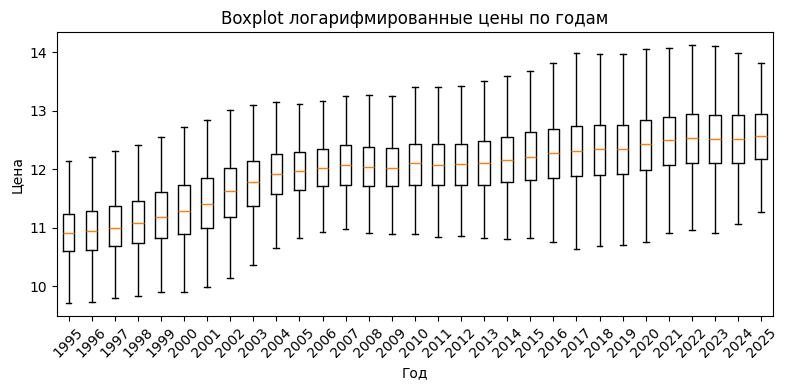

In [12]:
# 2. Boxplot цены по годам
from matplotlib import pyplot as plt

del outliers_df
gc.collect()
years = sorted(df['year'].dropna().unique())
data_by_year = [df.loc[df['year']==y, 'log_price'] for y in years if len(df.loc[df['year']==y])>0]
plt.figure(figsize=(8,4))
plt.boxplot(data_by_year, tick_labels=years, showfliers=True, flierprops=dict(marker='o', markersize=3))
plt.title('Boxplot логарифмированные цены по годам')
plt.xlabel('Год')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']

# Получаем список названий district, где число упоминаний < 100
low_count_districts = district_counts[district_counts['count'] < 100]['district'].tolist()

# Удаляем эти районы из основного датафрейма
df = df[~df['district'].isin(low_count_districts)]
del district_counts
gc.collect()

df['median_price_all_type'] = df.groupby(['type', 'old_new', 'duration', 'ppd_type', 'district', 'year', 'month'])['log_price'].transform('median')
df.head(10)

,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,log_price,median_price_all_type
335515,SA12 6NH,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,1995,5,128,9.741027,10.308986
627328,GL7 6ES,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,1995,9,243,10.778977,10.935907
191896,TW18 1AY,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,1995,11,313,11.370797,11.284552
462499,CF44 0HW,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,1995,6,166,10.558439,10.558439
345359,TS18 3LB,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,1995,7,183,10.239996,10.387487
97600,IP28 8UD,D,N,F,30,HAWTHORN WALK,BECK ROW,BURY ST. EDMUNDS,FOREST HEATH,SUFFOLK,A,1995,9,270,10.985310,11.152645
38302,S81 7NE,D,Y,F,12,BLENHEIM RISE,WORKSOP,WORKSOP,BASSETLAW,NOTTINGHAMSHIRE,A,1995,12,353,10.789340,11.001283
474163,FY8 3SN,T,N,L,29,ALEXANDRA ROAD,LYTHAM ST. ANNES,LYTHAM ST. ANNES,FYLDE,LANCASHIRE,A,1995,3,89,10.819798,10.719232
417113,NG13 8DF,T,N,F,117,GRANTHAM ROAD,BINGHAM,NOTTINGHAM,RUSHCLIFFE,NOTTINGHAMSHIRE,A,1995,1,16,10.551925,10.590390
659753,LA5 9LQ,T,N,F,12,NORTH ROAD,CARNFORTH,CARNFORTH,LANCASTER,LANCASHIRE,A,1995,2,33,10.859018,10.518700


In [14]:
big_city_set = {city.upper() for city in [
    'London', 'Birmingham', 'Leeds', 'Glasgow', 'Sheffield', 'Manchester',
    'Edinburgh', 'Liverpool', 'Bristol', 'Cardiff', 'Coventry', 'Belfast',
    'Nottingham', 'Brighton', 'Newcastle', 'Plymouth'
]}

def is_big_city(city):
    # Сравниваем город в верхнем регистре
    return True if city.upper() in big_city_set else False

df['is_big_city'] = df['town_city'].apply(is_big_city)

In [15]:
# Определим периоды кризисов в виде списков
crisis_periods = [
    (2008, 1, 2009, 12),  # Мировой финансовый кризис
    (2020, 1, 2020, 12)   # Пандемия COVID-19
]

df['is_crysis'] = 0

# Векторизованно добавляем 1 для строк, попадающих в периоды кризисов
for start_year, start_month, end_year, end_month in crisis_periods:
    # Условие для попадания в кризисный период
    is_in_period = (
        (df['year'] > start_year) | ((df['year'] == start_year) & (df['month'] >= start_month))
    ) & (
        (df['year'] < end_year) | ((df['year'] == end_year) & (df['month'] <= end_month))
    )
    
    # Обновляем значение 'is_crysis' для строк, попадающих в кризис
    df.loc[is_in_period, 'is_crysis'] = 1

df.head(5)

,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,log_price,median_price_all_type,is_big_city,is_crysis
335515,SA12 6NH,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,1995,5,128,9.741027,10.308986,False,0
627328,GL7 6ES,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,1995,9,243,10.778977,10.935907,False,0
191896,TW18 1AY,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,1995,11,313,11.370797,11.284552,False,0
462499,CF44 0HW,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,1995,6,166,10.558439,10.558439,False,0
345359,TS18 3LB,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,1995,7,183,10.239996,10.387487,False,0


In [16]:
df['loc_street'] = df['locality'].astype(str) + '-' + df['street'].astype(str)

In [17]:
# Добавим колонку с количеством сделок по locality и году
df['locality_year_count'] = df.groupby(['locality', 'year'])['locality'].transform('count')
df['locality_year_count'] = df['locality_year_count'].astype('int32')
df.head()

,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year,month,passed,log_price,median_price_all_type,is_big_city,is_crysis,loc_street,locality_year_count
335515,SA12 6NH,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,1995,5,128,9.741027,10.308986,False,0,PORT TALBOT-HENSHAW STREET,120
627328,GL7 6ES,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,1995,9,243,10.778977,10.935907,False,0,SIDDINGTON-THE TWENTIES,7
191896,TW18 1AY,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,1995,11,313,11.370797,11.284552,False,0,STAINES-STAINASH CRESCENT,225
462499,CF44 0HW,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,1995,6,166,10.558439,10.558439,False,0,ABERDARE-CONISTON RISE,86
345359,TS18 3LB,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,1995,7,183,10.239996,10.387487,False,0,STOCKTON-ON-TEES-DENNISON STREET,363


In [18]:
postcode_coords = pd.read_csv('./data/postcode_lat_long.csv')

df = df.merge(postcode_coords, on='postcode', how='left')

df.rename(columns={'latitude': 'latitude', 'longitude': 'longitude'}, inplace=True)
del postcode_coords
gc.collect()

df.drop(columns=['postcode'], inplace=True)
df.dropna(subset=["latitude", "longitude"], inplace=True)

df.head()

,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,...,month,passed,log_price,median_price_all_type,is_big_city,is_crysis,loc_street,locality_year_count,latitude,longitude
0,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,...,5,128,9.741027,10.308986,False,0,PORT TALBOT-HENSHAW STREET,120,51.611817,-3.770300
1,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,...,9,243,10.778977,10.935907,False,0,SIDDINGTON-THE TWENTIES,7,51.716703,-1.880654
2,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,...,11,313,11.370797,11.284552,False,0,STAINES-STAINASH CRESCENT,225,51.420250,-0.497750
3,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,...,6,166,10.558439,10.558439,False,0,ABERDARE-CONISTON RISE,86,51.732712,-3.482931
4,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,...,7,183,10.239996,10.387487,False,0,STOCKTON-ON-TEES-DENNISON STREET,363,54.561300,-1.324300


In [19]:
city_coords = pd.read_csv('./data/city_lat_long.csv')

df = df.merge(city_coords, on='town_city', how='left')

df.rename(columns={'city_lat': 'city_lat', 'city_lon': 'city_lon'}, inplace=True)
del city_coords
gc.collect()

df.dropna(subset=["city_lat", "city_lon"], inplace=True)

df.head()

,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,...,log_price,median_price_all_type,is_big_city,is_crysis,loc_street,locality_year_count,latitude,longitude,city_lat,city_lon
0,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,...,9.741027,10.308986,False,0,PORT TALBOT-HENSHAW STREET,120,51.611817,-3.770300,51.595235,-3.782415
1,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,...,10.778977,10.935907,False,0,SIDDINGTON-THE TWENTIES,7,51.716703,-1.880654,51.717103,-1.966162
2,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,...,11.370797,11.284552,False,0,STAINES-STAINASH CRESCENT,225,51.420250,-0.497750,51.434012,-0.511044
3,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,...,10.558439,10.558439,False,0,ABERDARE-CONISTON RISE,86,51.732712,-3.482931,51.713353,-3.445555
4,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,...,10.239996,10.387487,False,0,STOCKTON-ON-TEES-DENNISON STREET,363,54.561300,-1.324300,54.564094,-1.312916


In [20]:
# Считаем расстояние
df['dist_km'] = haversine(
    df['city_lat'], df['city_lon'],
    df['latitude'], df['longitude']
)

df[['latitude','longitude','city_lat','city_lon','dist_km']].head()

,latitude,longitude,city_lat,city_lon,dist_km
0,51.611817,-3.770300,51.595235,-3.782415,2.024724
1,51.716703,-1.880654,51.717103,-1.966162,5.890815
2,51.420250,-0.497750,51.434012,-0.511044,1.786398
3,51.732712,-3.482931,51.713353,-3.445555,3.355917
4,54.561300,-1.324300,54.564094,-1.312916,0.796974


In [21]:
from sklearn.neighbors import BallTree

R_EARTH_KM = 6371.0088

df_town_city_upper = df['town_city'].str.upper()
is_big_city_mask = df_town_city_upper.isin(big_city_set)

big_cities_coords_df = df.loc[is_big_city_mask, ['town_city', 'city_lat', 'city_lon']]
big_cities_coords_df = big_cities_coords_df.drop_duplicates(subset=['town_city'])

# Координаты всех точек в df (в радианах)
points_rad = np.radians(df[['latitude', 'longitude']].values)
# Координаты крупных городов (в радианах)
big_cities_rad = np.radians(big_cities_coords_df[['city_lat', 'city_lon']].values)

# Создание BallTree и запрос
tree = BallTree(big_cities_rad, metric='haversine')

# Ищем 1 ближайший город (k=1)
dists_rad, inds = tree.query(points_rad, k=1)

# Конвертация расстояний в километры и присвоение DataFrame
df['dist_to_big_city_km'] = dists_rad[:, 0] * R_EARTH_KM

In [22]:
df[['town_city', 'dist_km', 'dist_to_big_city_km']].head(5)

,town_city,dist_km,dist_to_big_city_km
0,PORT TALBOT,2.024724,43.361407
1,CIRENCESTER,5.890815,57.499097
2,STAINES,1.786398,27.403392
3,ABERDARE,3.355917,34.918322
4,STOCKTON-ON-TEES,0.796974,49.474117


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=128, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["median_price_all_type", "latitude", "longitude"]])
df["cluster"] = df["cluster"].astype("category")

df.head()

,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,...,is_crysis,loc_street,locality_year_count,latitude,longitude,city_lat,city_lon,dist_km,dist_to_big_city_km,cluster
0,T,N,F,23,HENSHAW STREET,PORT TALBOT,PORT TALBOT,PORT TALBOT,WEST GLAMORGAN,A,...,0,PORT TALBOT-HENSHAW STREET,120,51.611817,-3.770300,51.595235,-3.782415,2.024724,43.361407,124
1,T,N,F,8,THE TWENTIES,SIDDINGTON,CIRENCESTER,COTSWOLD,GLOUCESTERSHIRE,A,...,0,SIDDINGTON-THE TWENTIES,7,51.716703,-1.880654,51.717103,-1.966162,5.890815,57.499097,14
2,T,N,F,30,STAINASH CRESCENT,STAINES,STAINES,SPELTHORNE,SURREY,A,...,0,STAINES-STAINASH CRESCENT,225,51.420250,-0.497750,51.434012,-0.511044,1.786398,27.403392,76
3,S,N,F,45,CONISTON RISE,ABERDARE,ABERDARE,CYNON VALLEY,MID GLAMORGAN,A,...,0,ABERDARE-CONISTON RISE,86,51.732712,-3.482931,51.713353,-3.445555,3.355917,34.918322,91
4,T,N,F,6,DENNISON STREET,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,STOCKTON-ON-TEES,A,...,0,STOCKTON-ON-TEES-DENNISON STREET,363,54.561300,-1.324300,54.564094,-1.312916,0.796974,49.474117,40


In [24]:
print(df.columns.tolist())

['type', 'old_new', 'duration', 'PAON SAON', 'street', 'locality', 'town_city', 'district', 'county', 'ppd_type', 'year', 'month', 'passed', 'log_price', 'median_price_all_type', 'is_big_city', 'is_crysis', 'loc_street', 'locality_year_count', 'latitude', 'longitude', 'city_lat', 'city_lon', 'dist_km', 'dist_to_big_city_km', 'cluster']


# Preprocessing

In [ ]:
# --- Определение признаков ---
# Категориальные признаки с низкой кардинальностью
cat_low_cardinality = ['type', 'old_new', 'duration', 'ppd_type', 'is_big_city', 'is_crysis']
# Категориальные признаки с высокой кардинальностью
cat_high_cardinality = ['locality', 'street', 'town_city', 'district', 'county', 'loc_street', 'cluster']
# Числовые признаки (созданные из даты)
num_features = ['year', 'month', 'passed', 'median_price_all_type', 'dist_km', 'locality_year_count', 'dist_to_big_city_km']

# Проверка наличия всех колонок
all_features = cat_low_cardinality + cat_high_cardinality + num_features
missing_cols = [col for col in all_features if col not in df.columns]
if missing_cols:
    print(f"Error: Columns missing after feature engineering: {missing_cols}")
    exit()

In [26]:
# Оптимизация типов данных
for col in cat_low_cardinality + cat_high_cardinality:
    df[col] = df[col].astype('category')

df['year'] = df['year'].astype('int16')
df['month'] = df['month'].astype('int8') 
df['passed'] = df['passed'].astype('int32')
df['median_price_all_type'] = df['median_price_all_type'].astype('float32')
df['is_big_city'] = df['is_big_city'].astype('bool')
df['is_crysis'] = df['is_crysis'].astype('bool')
df['dist_km'] = df['dist_km'].astype('float32')
df['cluster'] = df['cluster'].astype('int16')

In [27]:
df.drop(columns=['PAON SAON'], inplace=True)

In [28]:
# TODO Add encoding for categorical features
# TODO Add scaling for numerical features

In [29]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = df[all_features]
y_log = df['log_price']

# Perform train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42, shuffle=True)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_log.shape}, y_test shape: {y_test_log.shape}")

X_train shape: (9173476, 20), X_test shape: (2293370, 20)
y_train shape: (9173476,), y_test shape: (2293370,)


In [30]:
del df, X, y_log
gc.collect()

36

In [31]:
print(X_train.columns[X_train.columns.duplicated()])

X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

assert X_train.columns.is_unique
assert X_test.columns.is_unique

Index([], dtype='object')


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Заглушка, можно заменить на StandardScaler()
])

# Пайплайн для категориальных признаков с низкой кардинальностью -> OrdinalEncoder
categorical_low_transformer = Pipeline(steps=[
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=13)) 
])

# Пайплайн для категориальных признаков с высокой кардинальностью -> TargetEncoding
categorical_high_transformer = Pipeline(steps=[
    ('target', TargetEncoder(handle_unknown='value', smoothing=0.2, return_df=False))
])

# Собираем все трансформеры в ColumnTransformer
# remainder='passthrough' сохранит колонки, не указанные явно (если такие есть)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat_low', categorical_low_transformer, cat_low_cardinality),
        ('cat_high', categorical_high_transformer, cat_high_cardinality)
    ],
    remainder='drop' # Игнорируем любые другие столбцы
)

# Model Training

In [33]:
import lightgbm as lgb

# --- Модель LightGBM ---
lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=1, objective='regression_l1')

# --- Создание полного пайплайна (препроцессор + модель) ---
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', lgbm)])

In [34]:
pipeline.fit(X_train, y_train_log)
y_pred_log = pipeline.predict(X_test)
print_metrics(y_test_log, y_pred_log, label="LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.813086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2792
[LightGBM] [Info] Number of data points in the train set: 9173476, number of used features: 20
[LightGBM] [Info] Start training from score 11.947956


c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSLE (LightGBM): 0.30116
MAE (LightGBM): £42,486.62


(np.float64(0.30115856145203124), 42486.617643944075)

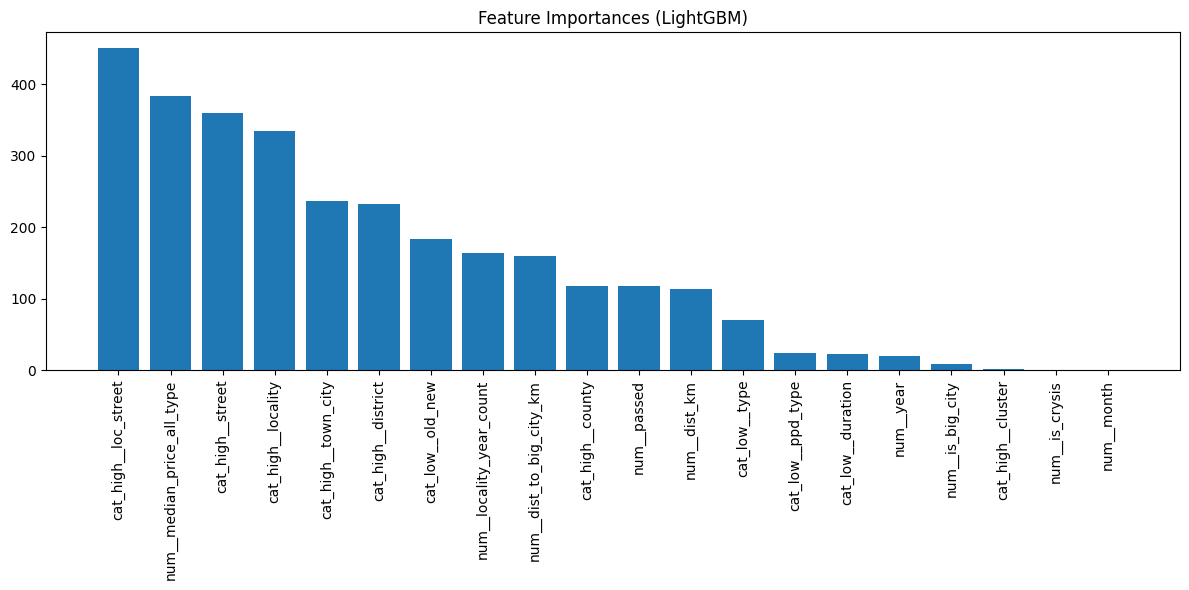

In [35]:
import matplotlib.pyplot as plt
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (LightGBM)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

# --- Создание полного пайплайна (препроцессор + модель) ---
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', xgb)])

pipeline.fit(X_train, y_train_log)
y_pred_log = pipeline.predict(X_test)
print_metrics(y_test_log, y_pred_log, label="XGBRegressor")

RMSLE (XGBRegressor): 0.29107
MAE (XGBRegressor): £41,708.06


(np.float64(0.2910662942637597), 41708.06030059356)

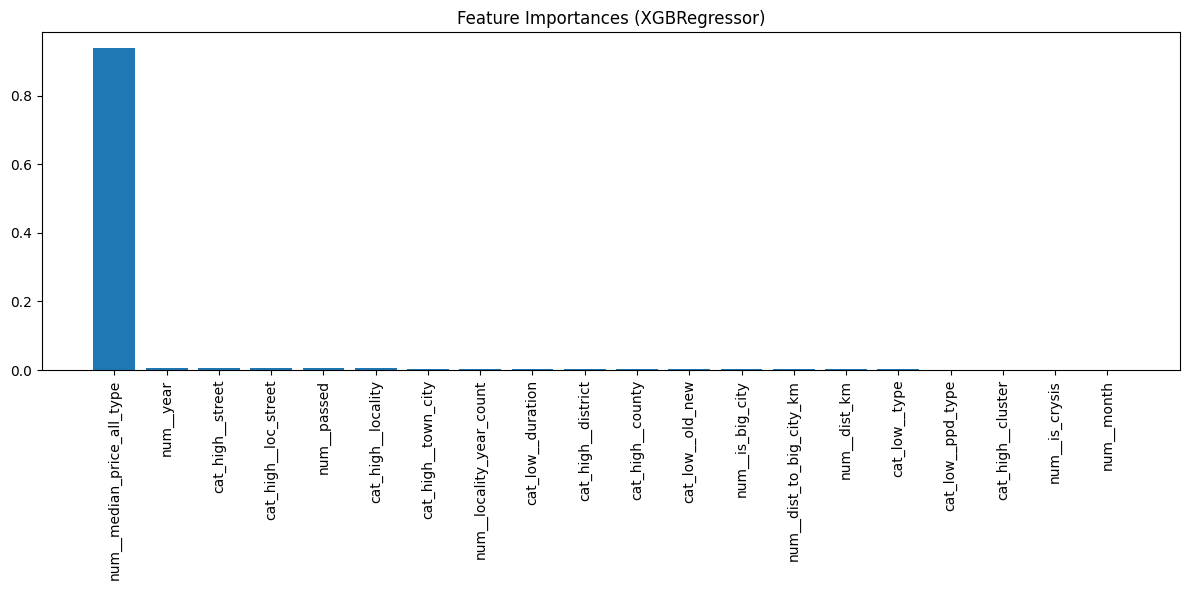

In [37]:
import matplotlib.pyplot as plt
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (XGBRegressor)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [38]:
raise KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
# Определяем сетку параметров для поиска
# Это примерные диапазоны, их можно и нужно корректировать
param_distributions = {
    'regressor__n_estimators': [500, 1000, 1500, 2000],
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'regressor__num_leaves': [31, 50, 70, 100],
    'regressor__max_depth': [-1, 10, 15, 20], # -1 означает без ограничения
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0], # feature_fraction
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],      # bagging_fraction
    'regressor__reg_alpha': [0, 0.01, 0.1, 1],         # L1 regularization
    'regressor__reg_lambda': [0, 0.01, 0.1, 1],        # L2 regularization
    # Параметры препроцессора тоже можно тюнить, например, smoothing у TargetEncoder
    'preprocessor__cat_high__target__smoothing': [1.0, 10.0, 50.0]
}

In [ ]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import RandomizedSearchCV

ss = ShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=10,  # Количество итераций
    cv=ss,  # Используем ShuffleSplit
    scoring=rmsle_log_scorer,  # Минимизируем MAE
    n_jobs=1,  # Используем все доступные ядра
    verbose=1,  # Выводим прогресс
    random_state=42
)

In [ ]:
# Запускаем поиск (на обучающих данных)
# TargetEncoder будет корректно обучаться на каждом трейн-фолде внутри CV
random_search.fit(X_train, y_train_log)

print(f"Best parameters found: {random_search.best_params_}")
print(f"Best RMSLE score on CV (log scale): {-random_search.best_score_:.5f}") # Знак минус, т.к. scorer был neg_rmsle

# Получаем лучшую модель из поиска
best_pipeline = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.230905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1995
[LightGBM] [Info] Number of data points in the train set: 7338780, number of used features: 17
[LightGBM] [Info] Start training from score 11.947956


c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.039171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1994
[LightGBM] [Info] Number of data points in the train set: 7338780, number of used features: 17
[LightGBM] [Info] Start training from score 11.949573


c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.727556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1992
[LightGBM] [Info] Number of data points in the train set: 7338780, number of used features: 17
[LightGBM] [Info] Start training from score 11.945688


c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.987312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1995
[LightGBM] [Info] Number of data points in the train set: 7338780, number of used features: 17
[LightGBM] [Info] Start training from score 11.947956


c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.560547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1994
[LightGBM] [Info] Number of data points in the train set: 7338780, number of used features: 17
[LightGBM] [Info] Start training from score 11.949573


KeyboardInterrupt: 

In [ ]:
best_pipeline.fit(X_train, y_train_log)

# --- Оценка на тестовом наборе ---
print("\nEvaluating on Test set...")
test_pred_log = best_pipeline.predict(X_test)
rmsle_test, mae_test = print_metrics(y_test_log, test_pred_log, label="Test")

In [ ]:
import seaborn as sns

# --- Анализ важности признаков ---
print("\nFeature Importances...")
try:
    # Получаем имена признаков ПОСЛЕ препроцессинга
    feature_names_out = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    lgbm_model = best_pipeline.named_steps['regressor']
    importances = lgbm_model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'feature': feature_names_out,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print(feature_importance_df.head(20))

    # Визуализация важности
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(25))
    plt.title('Top 25 Feature Importances (LightGBM)')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

except Exception as e:
    print(f"Could not retrieve feature importances: {e}")

In [ ]:
import joblib

# --- Сохранение модели ---
print("\nSaving the best pipeline...")
joblib.dump(best_pipeline, './model/house_price_pipeline_lgbm.joblib')
print("Pipeline saved to house_price_pipeline_lgbm.joblib")

In [ ]:
raise KeyboardInterrupt

In [ ]:
from xgboost import XGBRegressor

XGBR_model = XGBRegressor(
    enable_categorical=True,
)

XGBR_model.fit(X_train, y_train)
evaluate_model(XGBR_model)

Mean Absolute Error (MAE): 45678.1562
Mean Squared Error (MSE): 6027719168.0000
Root Mean Squared Error (RMSE): 77638.3872
R-squared (R²): 0.7515


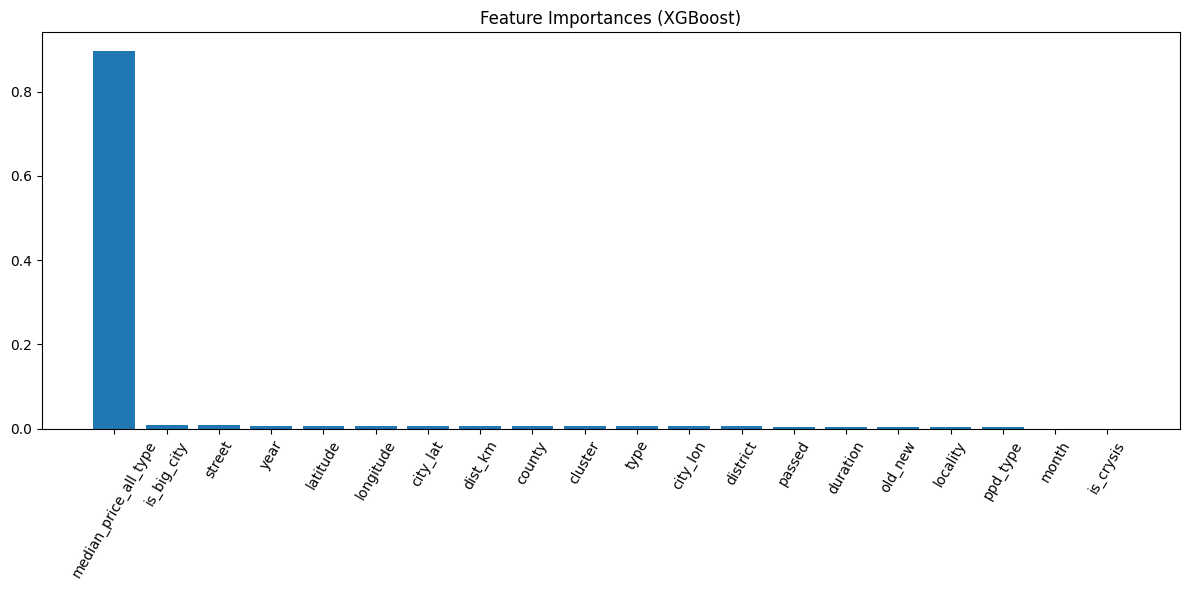

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBRegressor model
importances = XGBR_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (XGBoost)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=60)
plt.tight_layout()
plt.show()

In [ ]:
raise KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

RF_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1
)

RF_model.fit(X_train, y_train)
evaluate_model(RF_model)

Mean Absolute Error (MAE): 64956.9049
Mean Squared Error (MSE): 464865266537.7163
Root Mean Squared Error (RMSE): 681810.2863
R-squared (R²): 0.4289


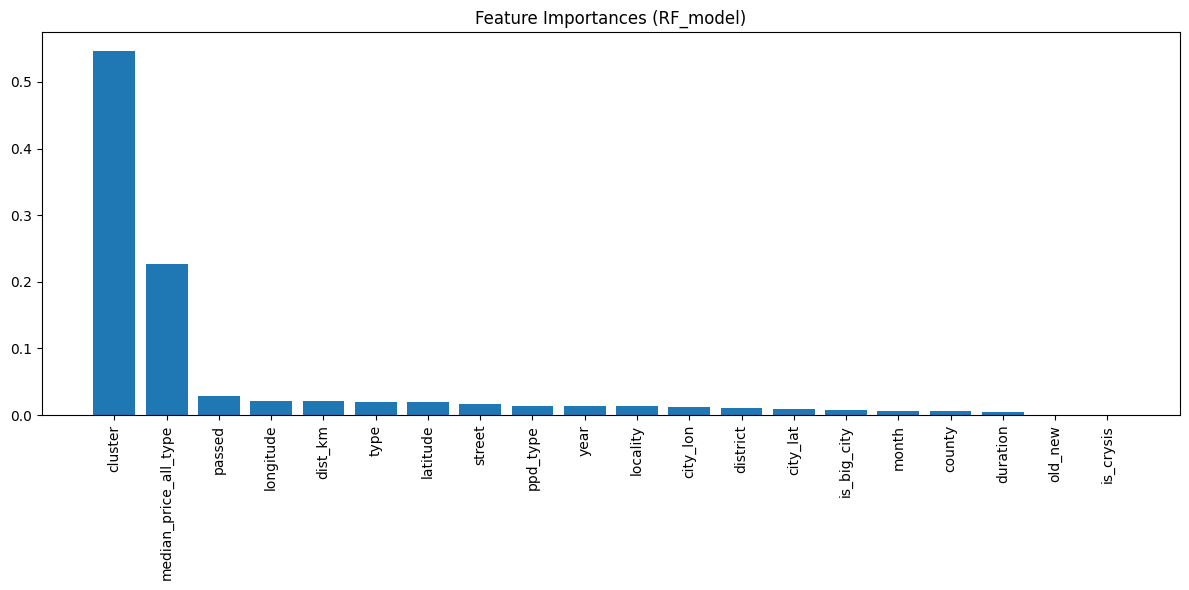

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBRegressor model
importances = RF_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (RF_model)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score


def objective(trial):

    n_estimators1 = trial.suggest_int("n_estimators", 4000, 6000, step=500)
    # L1 regularization weight.
    alpha1 = trial.suggest_float("alpha", 1e-8, 1e-5, log=True)
    # sampling ratio for training data.
    subsample1 = trial.suggest_float("subsample", 0.3, 0.5)
    # sampling according to each tree.
    colsample_bytree1 = trial.suggest_float("colsample_bytree", 0.35, 0.56)
    # maximum depth of the tree, signifies complexity of the tree.
    max_depth1 = trial.suggest_int("max_depth", 3, 7, step=2)
    # minimum child weight, larger the term more conservative the tree.
    min_child_weight1 = trial.suggest_int("min_child_weight", 1, 3)
    # learning rate
    learning_rate1 =  trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    # defines how selective algorithm is.
    gamma1 = trial.suggest_float("gamma", 1e-3, 1e-1, log=True)
       

        
    

    xgb_regressor = XGBRegressor(n_estimators = n_estimators1,alpha=alpha1,subsample=subsample1,colsample_bytree=colsample_bytree1,
                           max_depth=max_depth1,min_child_weight =min_child_weight1,learning_rate=learning_rate1,gamma=gamma1,eval_metric = 'mae',
                           random_state =1, enable_categorical=True)

    ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) #ShuffleSplit will help you to keep distributions of training data and folds similar)
    score = cross_val_score(xgb_regressor, X_train, y_train, scoring= make_scorer(mean_absolute_error),  cv=ss)
    score = score.mean()
    return score


sampler = TPESampler(seed=42) # create a seed for the sampler for reproducibility
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=30, n_jobs=1) # n_jobs = -1 will use all cores

[I 2025-05-13 18:13:15,492] A new study created in memory with name: no-name-ef58ad9c-071d-4487-9329-efaccfc08b09


[W 2025-05-13 18:13:39,607] Trial 0 failed with parameters: {'n_estimators': 4500, 'alpha': 7.114476009343412e-06, 'subsample': 0.446398788362281, 'colsample_bytree': 0.4757182816813777, 'max_depth': 3, 'min_child_weight': 1, 'learning_rate': 0.00013066739238053285, 'gamma': 0.05399484409787434} because of the following error: MemoryError((19247825,), dtype('int64')).
Traceback (most recent call last):
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Tema\AppData\Local\Temp\ipykernel_23664\1963810842.py", line 35, in objective
    score = cross_val_score(xgb_regressor, X_train, y_train, scoring= make_scorer(mean_absolute_error),  cv=ss)
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
  File "c:\Personal\ML\ROSIT2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 68

MemoryError: Unable to allocate 147. MiB for an array with shape (19247825,) and data type int64